In [2]:
import logging
from dataclasses import dataclass, field

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def print_dataclass(obj, indent_level=0):
    """
    Recursively prints all fields of a dataclass and its nested dataclasses.
    """
    # Check if the object is a dataclass instance
    if not isinstance(obj, type) or not issubclass(obj, dataclass):
        logger.info(f"{'  ' * indent_level}obj: {obj}")
        for key, value in obj.__dict__.items():
            logger.info(f"{'  ' * indent_level}{key}: {value}")
            # Check if the value is also a dataclass instance
            if isinstance(value, type) or (isinstance(obj, dataclass) and hasattr(obj, '__dataclass_fields__')):
                print_dataclass(value, indent_level + 1)
        return

    for field in obj.__dataclass_fields__.values():
        logger.info(f"{'  ' * indent_level}{field.name}: {getattr(obj, field.name)}")
        value = getattr(obj, field.name)
        # Check if the value is a dataclass instance
        if isinstance(value, type) or (isinstance(obj, dataclass) and hasattr(value, '__dataclass_fields__')):
            print_dataclass(value, indent_level + 1)

# Example usage with nested dataclasses

@dataclass
class Address:
    street: str = "Main Street"
    number: int = 123
    city: str = "New York"

@dataclass
class Person:
    name: str = "John Doe"
    age: int = 30
    address: Address = field(default_factory=Address())

# Create a person instance to print
person = Person()

# Print all attributes and nested dataclasses
logger.info("Printing dataclass details:")
print_dataclass(person)


TypeError: 'Address' object is not callable


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1804
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      799

Total number of variables............................:      800
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      800
                     variables with only upper bounds:        0
Total number of equality constraints.................:      402
Total number of inequality c

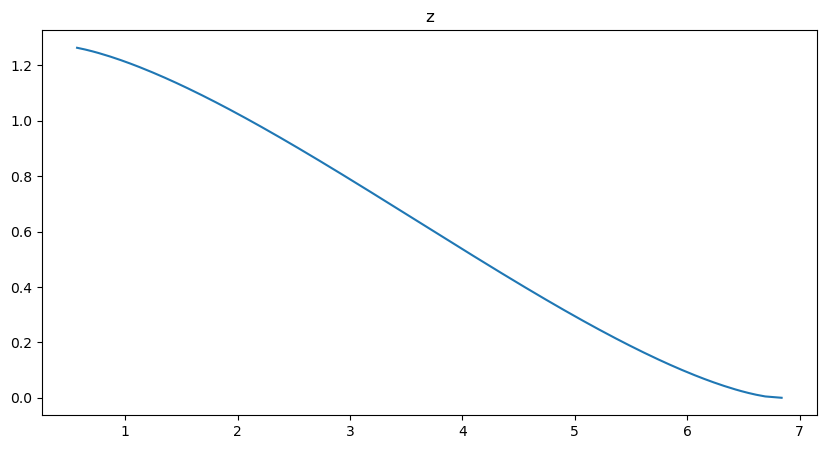

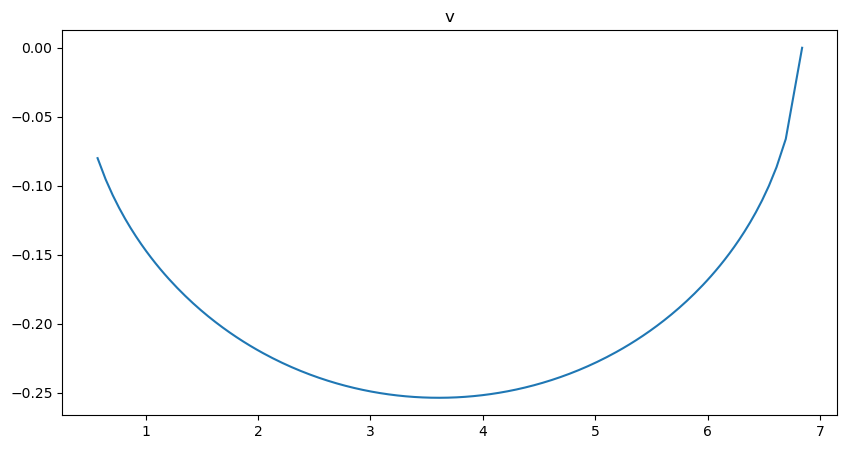

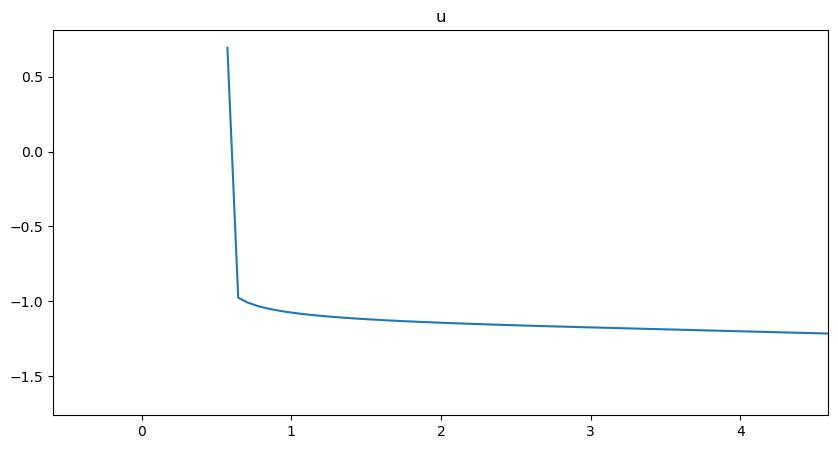

In [3]:
import casadi as ca
import screwCalculus as sc
import numpy as np
import matplotlib.pyplot as plt

m = 1
k = 10
c = 1
g = 9.81

z = ca.SX.sym('s')
v = ca.SX.sym('v')

u = ca.SX.sym('u')

w = ca.SX.sym('w')

dyn_expr = ca.vertcat(v,
                      -1/m*(c + k +u - g))

dyn_fun = ca.Function('dyn', [ca.vertcat(z, v), u], [dyn_expr])

x0 = ca.vertcat(1,1)

W = []
W0 = []
W_lb = []
W_ub = []

g = []

J = 0

N = 200

X_k_1 = x0

for ii in range(0, N):

    X_k = ca.SX.sym(f'X_{ii+1}', 2, 1)
    U_k = ca.SX.sym(f'U_{ii+1}', 1, 1)
    t_k = ca.SX.sym(f't_{ii+1}', 1, 1)

    X_dot = dyn_fun(X_k_1, U_k)

    X_int = sc.RK4_step(X_k_1, U_k, dyn_fun, t_k)

    g.append(X_int - X_k)
    W.append(X_k)
    W.append(U_k)
    W.append(t_k)

    W0.append(ca.vertcat(0,0,5,0.5))
    W_lb.append(ca.vertcat(-100,-100,-50,0))
    W_ub.append(ca.vertcat(100,100,50,5))
    J+= t_k**2 + w*X_dot[1]**2
    X_k_1 = X_k

g.append(X_int - ca.vertcat(0,0))


problem = {'x': ca.vertcat(*W), 'f': J, 'g': ca.vertcat(*g), 'p':w}

solver = ca.nlpsol('S', 'ipopt',problem)
sol = solver(x0 = ca.vertcat(*W0), ubx=  ca.vertcat(*W_ub), lbx= ca.vertcat(*W_lb), lbg= 0, ubg= 0, p = 0.1)

res =  sol['x'].full()

res = np.reshape(res, (4,-1), order='F')
z_ref = res[0,:].reshape(1,-1)
v_ref = res[1,:].reshape(1,-1)
u_ref = res[2,:].reshape(1,-1)
dt = res[3,:].reshape(1,-1)
t = np.cumsum(dt).reshape(1,-1)


plt.figure(figsize=(10, 5)); plt.title('z')
plt.plot(t.T, z_ref.T)
plt.figure(figsize=(10, 5)); plt.title('v')
plt.plot(t.T, v_ref.T)
plt.figure(figsize=(10, 5)); plt.title('u')
plt.plot(t.T, u_ref.T)
# plt.quiver(profile_points[0, :], profile_points[1, :], normals_points[0, :], normals_points[1, :])
plt.axis('equal')
plt.xlim(0, 4)
plt.show()


In [4]:
a = ca.SX.sym('a')



sol_lower = solver(x0 = ca.vertcat(*W0), ubx =  ca.vertcat(*W_ub), lbx= ca.vertcat(*W_lb), lbg = 0, ubg = 0, p = a)


sol_lower = ca.reshape(sol_lower['x'], 4, N)

z_opt = sol_lower[0,:]
v_opt = sol_lower[1,:]
u_opt = sol_lower[2,:]

print(u_opt.shape)
print(u_ref.shape)
J_upper = ca.sum2((z_opt - z_ref)**2)+ca.sum2((v_opt - v_ref)**2)+ca.sum2((u_opt - u_ref)**2)

print(J_upper.shape)
problem_upper = {'x': a, 'f': J_upper}

solver_upper = ca.nlpsol('Su', 'ipopt', problem_upper)

sol = solver_upper(x0 = 1, lbx = 0, ubx = 10)

RuntimeError: Error in Function::call for 'S' [IpoptInterface] at .../casadi/core/function.cpp:1441:
Error in Function::call for 'S' [IpoptInterface] at .../casadi/core/function.cpp:370:
.../casadi/core/function_internal.cpp:2024: 'eval_sx' not defined for IpoptInterface